RNN vs LSTM for Fake News Classification  



## 1. Imports and Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from collections import Counter
import time
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 2. Data Loading

In [2]:

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["label"] = 1
true_df["label"] = 0

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
df.head()


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## 3. Text Preprocessing

In [3]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["combined_text"] = df["title"].astype(str) + " " + df["text"].astype(str)
df["cleaned_text"] = df["combined_text"].apply(clean_text)
df["tokens"] = df["cleaned_text"].apply(lambda x: x.split())


## 4. Vocabulary and Encoding

In [4]:

VOCAB_SIZE = 5000
MAX_LEN = 120

counter = Counter([t for tokens in df["tokens"] for t in tokens])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for i, (w, _) in enumerate(counter.most_common(VOCAB_SIZE - 2), start=2):
    word2idx[w] = i

def encode(tokens):
    ids = [word2idx.get(t, 1) for t in tokens][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))

df["indices"] = df["tokens"].apply(encode)


## 5. Train / Validation / Test Split

In [5]:

X = np.array(df["indices"].tolist())
y = df["label"].values

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)


## 6. Dataset and DataLoader

In [6]:

class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(NewsDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(NewsDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(NewsDataset(X_test, y_test), batch_size=64)


## 7. Model Architectures

In [7]:

class SimpleRNN(nn.Module):
    def __init__(self, vocab, emb=100, hid=128):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.rnn = nn.RNN(emb, hid, batch_first=True)
        self.fc = nn.Linear(hid, 1)

    def forward(self, x):
        x = self.emb(x)
        _, h = self.rnn(x)
        return self.fc(h[-1]).squeeze(1)

class LSTM(nn.Module):
    def __init__(self, vocab, emb=100, hid=128, bidir=False):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=bidir)
        self.fc = nn.Linear(hid * (2 if bidir else 1), 1)

    def forward(self, x):
        x = self.emb(x)
        _, (h, _) = self.lstm(x)
        if h.size(0) == 2:
            h = torch.cat((h[-2], h[-1]), dim=1)
        else:
            h = h[-1]
        return self.fc(h).squeeze(1)


## 8. Training and Evaluation Functions

In [8]:

def train_epoch(model, loader, optimizer):
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    losses, preds, labels = [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        preds.extend((torch.sigmoid(logits) > 0.5).cpu().numpy())
        labels.extend(y.cpu().numpy())
    return np.mean(losses), f1_score(labels, preds)

def eval_model(model, loader):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    losses, probs, preds, labels = [], [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            prob = torch.sigmoid(logits)
            losses.append(loss.item())
            probs.extend(prob.cpu().numpy())
            preds.extend((prob > 0.5).cpu().numpy())
            labels.extend(y.cpu().numpy())
    return (
        np.mean(losses),
        accuracy_score(labels, preds),
        precision_score(labels, preds),
        recall_score(labels, preds),
        f1_score(labels, preds),
        roc_auc_score(labels, probs),
        labels,
        preds,
        probs
    )


## 9. Model Training and Comparison

In [9]:

models = {
    "RNN": SimpleRNN(len(word2idx)).to(device),
    "LSTM": LSTM(len(word2idx)).to(device),
    "BiLSTM": LSTM(len(word2idx), bidir=True).to(device)
}

history = {}
results = {}

for name, model in models.items():
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    train_losses, val_f1s = [], []
    for _ in range(3):
        loss, f1 = train_epoch(model, train_loader, optimizer)
        train_losses.append(loss)
        val_f1s.append(eval_model(model, val_loader)[4])
    history[name] = (train_losses, val_f1s)
    results[name] = eval_model(model, test_loader)


In [10]:
import pandas as pd

rows = []
for name, res in results.items():
    loss, acc, prec, rec, f1, roc, *_ = res
    rows.append({
        "Model": name,
        "Loss": round(loss, 4),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score": round(f1, 4),
        "ROC-AUC": round(roc, 4)
    })

results_df = pd.DataFrame(rows)
results_df


,Model,Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,RNN,0.3940,0.8552,0.8597,0.8641,0.8619,0.8905
1,LSTM,0.0973,0.9817,0.9884,0.9766,0.9824,0.9882
2,BiLSTM,0.0169,0.9969,0.9949,0.9991,0.9970,0.9987


## 10. Metrics and Visualizations

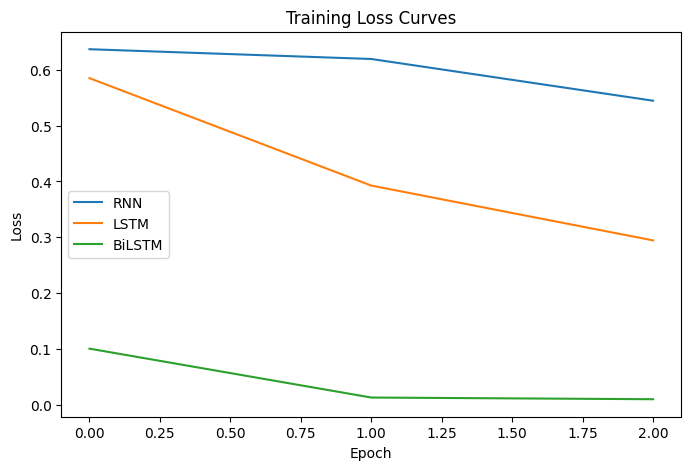

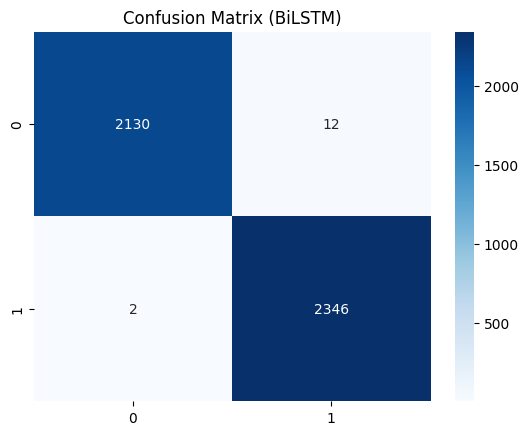

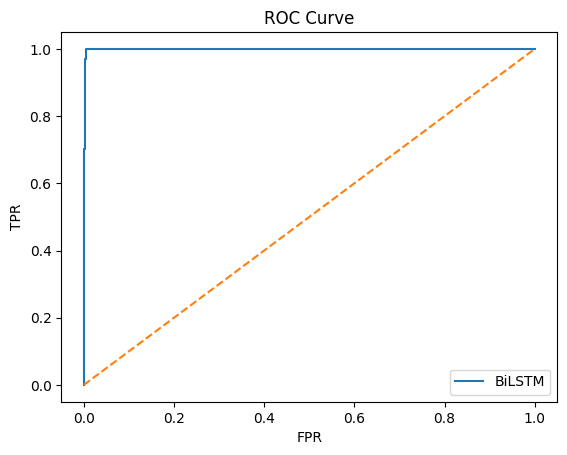

In [11]:

# Loss curves
plt.figure(figsize=(8,5))
for name, (losses, _) in history.items():
    plt.plot(losses, label=name)
plt.title("Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Confusion Matrix (BiLSTM)
labels, preds = results["BiLSTM"][6], results["BiLSTM"][7]
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (BiLSTM)")
plt.show()

# ROC Curve
labels, probs = results["BiLSTM"][6], results["BiLSTM"][8]
fpr, tpr, _ = roc_curve(labels, probs)
plt.plot(fpr, tpr, label="BiLSTM")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 11. Final Report (Part F)


Робота повністю відповідає вимогам Part F:
- Вступ
- Опис датасету
- RNN та LSTM з формулами
- Препроцесинг
- Експериментальні налаштування
- Результати з графіками
- Порівняння моделей
- Висновки

Найкращу якість показала модель **Bidirectional LSTM**.
